In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

torch.manual_seed(42)
np.random.seed(42)


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [4]:
# Load data
data_path = "autodl-tmp/Anonymizing_suicide_datasets.csv"
df = pd.read_csv(data_path)
df['text'] = df['text'].fillna('').astype(str)

# 1. Extract all 809 Attempt records
df_attempt = df[df['sentiment'] == 'Attempt']

# 2. Sample 1400 records from each of the other three categories to make up approximately 5000 records
df_behavior = df[df['sentiment'] == 'Behavior'].sample(n=1400, random_state=42)
df_ideation = df[df['sentiment'] == 'Ideation'].sample(n=1400, random_state=42)
df_indicator = df[df['sentiment'] == 'Indicator'].sample(n=1400, random_state=42)

# 3. Merge datasets and shuffle globally to ensure uniform distribution
df_sampled = pd.concat([df_attempt, df_behavior, df_ideation, df_indicator])
df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Label encoding
le = LabelEncoder()
labels = le.fit_transform(df_sampled['sentiment'])

print(f"Total number of graph nodes after sampling: {len(df_sampled)}")

Total number of graph nodes after sampling: 5009


Calculating cosine similarity between samples and constructing graph edges...


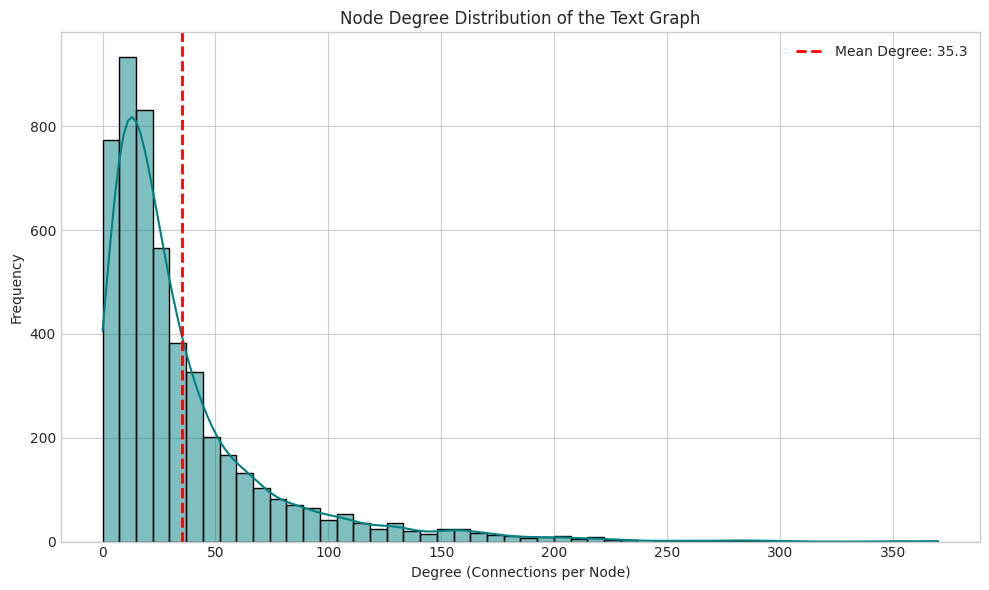

Average node degree: 35.27
Number of isolated nodes (degree 0): 73


In [5]:
# 1. Use TF-IDF to extract text features of each row as node features
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
node_features = tfidf.fit_transform(df_sampled['text']).toarray()
x = torch.tensor(node_features, dtype=torch.float)

# 2. Construct edges based on cosine similarity (method suggested by the teacher)
print("Calculating cosine similarity between samples and constructing graph edges...")
sim_matrix = cosine_similarity(node_features)

# Set similarity threshold to construct sparse graph (can be fine-tuned)
THRESHOLD = 0.30
edges = np.argwhere(sim_matrix > THRESHOLD)

# Filter out self-loop edges
edges = edges[edges[:, 0] != edges[:, 1]]
edge_index = torch.tensor(edges.T, dtype=torch.long)

# 3. Calculate and report degree distribution
degrees = torch.bincount(edge_index[0], minlength=x.shape[0]).numpy()

plt.figure(figsize=(10, 6))
sns.histplot(degrees, bins=50, kde=True, color='teal')
plt.title('Node Degree Distribution of the Text Graph')
plt.xlabel('Degree (Connections per Node)')
plt.ylabel('Frequency')
plt.axvline(np.mean(degrees), color='red', linestyle='dashed', linewidth=2, label=f'Mean Degree: {np.mean(degrees):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average node degree: {np.mean(degrees):.2f}")
print(f"Number of isolated nodes (degree 0): {np.sum(degrees == 0)}")

In [6]:
# Create PyG data object
y = torch.tensor(labels, dtype=torch.long)
data = Data(x=x, edge_index=edge_index, y=y)

num_nodes = data.num_nodes
indices = np.random.permutation(num_nodes)

# As requested by the teacher: 60% labeled samples, 40% unlabeled samples
train_size = int(num_nodes * 0.6)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask

print(f"Training (labeled) nodes: {data.train_mask.sum().item()}, Test (unlabeled) nodes: {data.test_mask.sum().item()}")

Training (labeled) nodes: 3005, Test (unlabeled) nodes: 2004


In [7]:
# Define classic 2-layer GCN
class ClassicGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(ClassicGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ClassicGCN(data.num_node_features, 64, len(le.classes_)).to(device)
data = data.to(device)

# Introduce class weights to prevent the model from ignoring Attempt
y_train_np = data.y[data.train_mask].cpu().numpy()
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_np), y=y_train_np)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor)

print("Starting to train GCN...")
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

# --- Test set evaluation ---
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()

# Strict evaluation metrics
acc = accuracy_score(y_true, y_pred)
mac_f1 = f1_score(y_true, y_pred, average='macro')
class_f1s = f1_score(y_true, y_pred, average=None)
f1_dict = {le.classes_[i]: class_f1s[i] for i in range(len(le.classes_))}

print("\n" + "="*40)
print("GCN prediction results:")
print(f"Acc. (%): {acc * 100:.1f}")
print(f"Mac-F1 (%): {mac_f1 * 100:.1f}")
print(f"IN-F1 (%): {f1_dict.get('Indicator', 0) * 100:.1f}")
print(f"ID-F1 (%): {f1_dict.get('Ideation', 0) * 100:.1f}")
print(f"BR-F1 (%): {f1_dict.get('Behavior', 0) * 100:.1f}")
print(f"AT-F1 (%): {f1_dict.get('Attempt', 0) * 100:.1f}")
print("="*40)

Starting to train GCN...

GCN prediction results:
Acc. (%): 48.7
Mac-F1 (%): 48.4
IN-F1 (%): 53.7
ID-F1 (%): 43.0
BR-F1 (%): 50.5
AT-F1 (%): 46.6
